# Root Finding with Constraints: Reaction Equilibrium

This notebook demonstrates GMM and Flow Matching approaches for solving constrained root finding problems.

**Authors:** Victor Alves and John R. Kitchin

## System Information

This section documents the computational environment used to run this notebook.

In [1]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.12.8 (main, Jan 14 2025, 23:36:58) [Clang 19.1.6 ]
Platform: macOS-15.7.2-arm64-arm-64bit
Processor: arm
CPU count: 14 physical, 14 logical
Total memory: 64.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.3.4
scipy                1.16.2
matplotlib           3.10.1


sklearn              1.7.2


torch                2.4.1
gmr                  2.0.2
----------------------------------------------------------------------

Notebook execution started: 2025-12-18 10:13:51
Initial memory usage: 320.03 MB


## System Information

This section documents the computational environment used to run this notebook.

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    ConditionalFlowMatching
)

# Figure settings for publication
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10

warnings.filterwarnings('ignore')

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete")

Setup complete


---
## Root Finding with Constraints: Reaction Equilibrium

Consider the reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor. We seek the equilibrium extent of reaction $\xi$ where concentrations must remain non-negative.

With initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$  
- $C_C = 2\xi$

The equilibrium condition:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Root finding formulation:** Find $\xi$ where:
$$f(\xi) = K_{eq}(1-\xi)^2 - 4\xi^2 = 0$$

**Physical constraints:** Concentrations must be non-negative, so $0 < \xi < 1$

**GMM approach:** We sample $\xi$ only in the feasible region, train a GMM on $[\xi, f(\xi)]$, and condition on $f(\xi) = 0$ to find the root.

In [3]:
# Reaction equilibrium: A + B ⇌ 2C
# Parameters
Keq = 1.0  # Equilibrium constant (changed to show two roots)

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=1: (1-ξ)² = 4ξ² → 1-ξ = ±2ξ
# Physical root: 1-ξ = 2ξ → ξ = 1/3
# Unphysical root: 1-ξ = -2ξ → ξ = -1 (negative CA, CB!)
xi_physical = 1/3
xi_unphysical = -1

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"\nAnalytical solutions (two mathematical roots):")
print(f"  Physical root:     ξ = {xi_physical:.4f} (CA=CB={1-xi_physical:.2f}, CC={2*xi_physical:.2f})")
print(f"  Unphysical root:   ξ = {xi_unphysical:.4f} (CA=CB={1-xi_unphysical:.2f}, CC={2*xi_unphysical:.2f})")
print(f"\nNote: The unphysical root gives CA > initial concentration!")

# Verify with scipy
from scipy.optimize import minimize_scalar

def residual(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

# Find the physical root
result_scipy = minimize_scalar(lambda x: residual(x)**2, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification (physical root): ξ = {result_scipy.x:.6f}")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 1.0

Analytical solutions (two mathematical roots):
  Physical root:     ξ = 0.3333 (CA=CB=0.67, CC=0.67)
  Unphysical root:   ξ = -1.0000 (CA=CB=2.00, CC=-2.00)

Note: The unphysical root gives CA > initial concentration!

Scipy verification (physical root): ξ = 0.333334


### Train GMM for Reaction Equilibrium

In [4]:
# For ROOT FINDING, we condition on the residual = 0
# We'll train TWO models to demonstrate the effect of constraints:
# 1. CONSTRAINED: sample only in physical region (0 < ξ < 1)
# 2. UNCONSTRAINED: sample broader region to capture both roots

def residual(xi):
    """Equilibrium residual - should equal zero at solution."""
    return Keq * (1 - xi)**2 - 4 * xi**2

n_eq_samples = 2000
np.random.seed(42)

# CONSTRAINED MODEL: sample only in feasible region
xi_samples_constrained = np.random.uniform(0.01, 0.99, n_eq_samples)
residuals_constrained = np.array([residual(xi) for xi in xi_samples_constrained])
data_eq_constrained = np.column_stack([xi_samples_constrained, residuals_constrained])

print("CONSTRAINED MODEL (physical region only)")
print(f"  ξ range: [{xi_samples_constrained.min():.3f}, {xi_samples_constrained.max():.3f}]")
print(f"  Residual range: [{residuals_constrained.min():.3f}, {residuals_constrained.max():.3f}]")

# UNCONSTRAINED MODEL: sample broader region including unphysical root
xi_samples_unconstrained = np.random.uniform(-1.5, 1.5, n_eq_samples)
residuals_unconstrained = np.array([residual(xi) for xi in xi_samples_unconstrained])
data_eq_unconstrained = np.column_stack([xi_samples_unconstrained, residuals_unconstrained])

print(f"\nUNCONSTRAINED MODEL (includes unphysical region)")
print(f"  ξ range: [{xi_samples_unconstrained.min():.3f}, {xi_samples_unconstrained.max():.3f}]")
print(f"  Residual range: [{residuals_unconstrained.min():.3f}, {residuals_unconstrained.max():.3f}]")

# Verify both roots
print(f"\nVerification:")
print(f"  f({xi_physical:.3f}) = {residual(xi_physical):.6f} (physical root)")
print(f"  f({xi_unphysical:.3f}) = {residual(xi_unphysical):.6f} (unphysical root)")

# Train both GMMs
print(f"\n{'='*60}")
print("Training CONSTRAINED GMM...")
gmm_constrained, gmm_constrained_info = best_gmm(data_eq_constrained, verbose=False)
print(f"Best GMM: {gmm_constrained_info['best_k']} components")

print(f"\nTraining UNCONSTRAINED GMM...")
gmm_unconstrained, gmm_unconstrained_info = best_gmm(data_eq_unconstrained, verbose=False)
print(f"Best GMM: {gmm_unconstrained_info['best_k']} components")

CONSTRAINED MODEL (physical region only)
  ξ range: [0.013, 0.990]
  Residual range: [-3.918, 0.973]

UNCONSTRAINED MODEL (includes unphysical region)
  ξ range: [-1.500, 1.499]
  Residual range: [-8.735, 1.333]

Verification:
  f(0.333) = 0.000000 (physical root)
  f(-1.000) = 0.000000 (unphysical root)

Training CONSTRAINED GMM...


Best GMM: 21 components

Training UNCONSTRAINED GMM...


Best GMM: 47 components


In [5]:
# Sample from both GMMs: condition on residual = 0

# CONSTRAINED GMM (should find only physical root)
c_gmm_constrained = gmm_constrained.condition([1], [[0.0]])
xi_gmm_constrained = c_gmm_constrained.sample(1000)[:, 0]

print("CONSTRAINED GMM Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_gmm_constrained.mean():.4f} ± {xi_gmm_constrained.std():.4f}")
print(f"  Analytical (physical): ξ = {xi_physical:.4f}")
print(f"  Residual at mean: {residual(xi_gmm_constrained.mean()):.6f}")

# UNCONSTRAINED GMM (should find both roots!)
c_gmm_unconstrained = gmm_unconstrained.condition([1], [[0.0]])
xi_gmm_unconstrained = c_gmm_unconstrained.sample(1000)[:, 0]

print(f"\nUNCONSTRAINED GMM Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_gmm_unconstrained.mean():.4f} ± {xi_gmm_unconstrained.std():.4f}")
print(f"  Note: The distribution should show TWO peaks")

# Check if we got both roots
physical_samples = xi_gmm_unconstrained[(xi_gmm_unconstrained > 0) & (xi_gmm_unconstrained < 1)]
unphysical_samples = xi_gmm_unconstrained[xi_gmm_unconstrained < 0]

print(f"\n  Physical samples:   {len(physical_samples)} (ξ ≈ {physical_samples.mean():.3f})")
print(f"  Unphysical samples: {len(unphysical_samples)} (ξ ≈ {unphysical_samples.mean() if len(unphysical_samples) > 0 else 0:.3f})")

CONSTRAINED GMM Solution (conditioning on f(ξ) = 0):
  ξ = 0.3334 ± 0.0011
  Analytical (physical): ξ = 0.3333
  Residual at mean: -0.000250

UNCONSTRAINED GMM Solution (conditioning on f(ξ) = 0):
  ξ = -0.4745 ± 0.6514
  Note: The distribution should show TWO peaks

  Physical samples:   394 (ξ ≈ 0.333)
  Unphysical samples: 606 (ξ ≈ -1.000)


### Train Flow Matching for Reaction Equilibrium

In [6]:
# Train Flow Matching models for both constrained and unconstrained cases
# x_data: ξ values to generate
# c_data: residual values to condition on

# CONSTRAINED Flow Matching
x_data_constrained = xi_samples_constrained.reshape(-1, 1)
c_data_constrained = residuals_constrained.reshape(-1, 1)

fm_constrained = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
print("Training CONSTRAINED Flow Matching...")
fm_constrained_history = fm_constrained.fit(x_data_constrained, c_data_constrained, epochs=2000, batch_size=64, verbose=False)
print("  Training complete")

# UNCONSTRAINED Flow Matching
x_data_unconstrained = xi_samples_unconstrained.reshape(-1, 1)
c_data_unconstrained = residuals_unconstrained.reshape(-1, 1)

fm_unconstrained = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
print("\nTraining UNCONSTRAINED Flow Matching...")
fm_unconstrained_history = fm_unconstrained.fit(x_data_unconstrained, c_data_unconstrained, epochs=2000, batch_size=64, verbose=False)
print("  Training complete")

Training CONSTRAINED Flow Matching...


  Training complete

Training UNCONSTRAINED Flow Matching...


  Training complete


In [7]:
# Sample from both Flow Matching models: condition on residual = 0

# CONSTRAINED FM (should find only physical root)
xi_fm_constrained = fm_constrained.sample(c_values=[[0.0]], n_samples=1000, n_steps=200)[:, 0]

print("CONSTRAINED Flow Matching Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_fm_constrained.mean():.4f} ± {xi_fm_constrained.std():.4f}")
print(f"  Analytical (physical): ξ = {xi_physical:.4f}")
print(f"  Residual at mean: {residual(xi_fm_constrained.mean()):.6f}")

# UNCONSTRAINED FM (should find both roots!)
xi_fm_unconstrained = fm_unconstrained.sample(c_values=[[0.0]], n_samples=1000, n_steps=200)[:, 0]

print(f"\nUNCONSTRAINED Flow Matching Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_fm_unconstrained.mean():.4f} ± {xi_fm_unconstrained.std():.4f}")
print(f"  Note: The distribution should show TWO peaks")

# Check if we got both roots
physical_samples_fm = xi_fm_unconstrained[(xi_fm_unconstrained > 0) & (xi_fm_unconstrained < 1)]
unphysical_samples_fm = xi_fm_unconstrained[xi_fm_unconstrained < 0]

print(f"\n  Physical samples:   {len(physical_samples_fm)} (ξ ≈ {physical_samples_fm.mean():.3f})")
print(f"  Unphysical samples: {len(unphysical_samples_fm)} (ξ ≈ {unphysical_samples_fm.mean() if len(unphysical_samples_fm) > 0 else 0:.3f})")

CONSTRAINED Flow Matching Solution (conditioning on f(ξ) = 0):
  ξ = 0.3331 ± 0.0018
  Analytical (physical): ξ = 0.3333
  Residual at mean: 0.000843

UNCONSTRAINED Flow Matching Solution (conditioning on f(ξ) = 0):
  ξ = -0.2688 ± 0.6553
  Note: The distribution should show TWO peaks

  Physical samples:   546 (ξ ≈ 0.329)
  Unphysical samples: 454 (ξ ≈ -0.987)


### Publication Figure: Reaction Equilibrium Root Finding

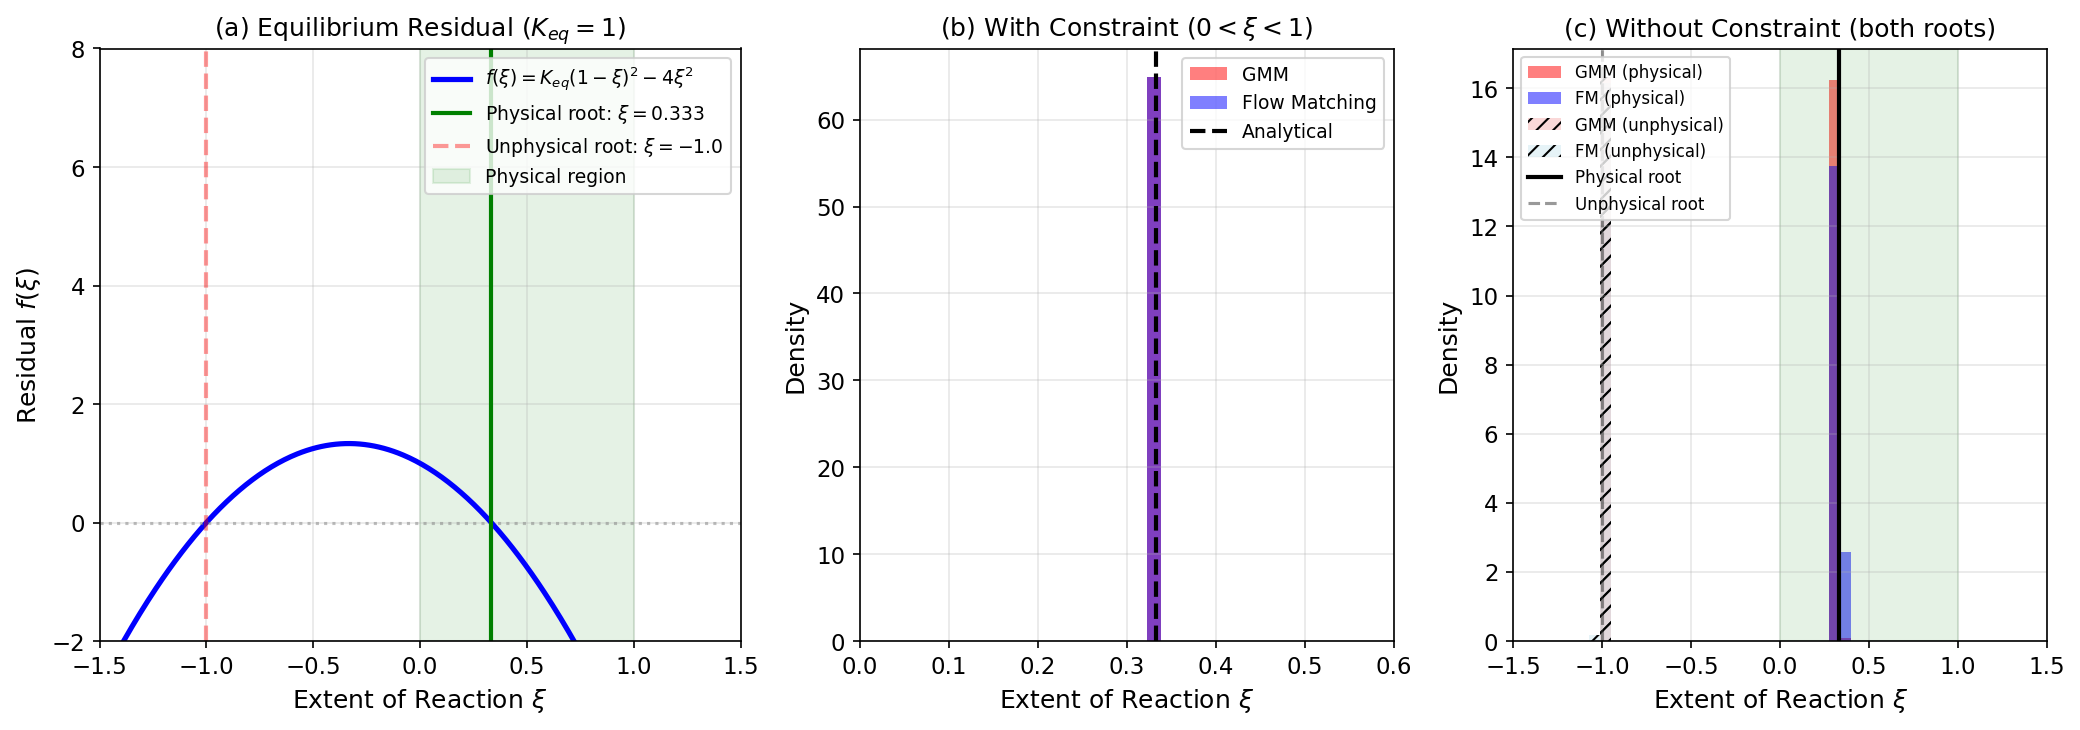


Figure saved as 'equilibrium_comparison.png'

Key insight: Without constraints, the model finds BOTH mathematical roots,
but only the physical root (ξ ≈ 0.33) makes sense for this chemistry problem!


In [8]:
# Create publication figure: 3-panel layout showing effect of constraints
fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1, 1])

# ============================================================
# Left: Residual function showing both roots
# ============================================================
ax1 = fig.add_subplot(gs[0])
xi_plot = np.linspace(-1.5, 1.5, 400)
f_plot = np.array([residual(x) for x in xi_plot])

ax1.plot(xi_plot, f_plot, 'b-', lw=2.5, label='$f(\\xi) = K_{eq}(1-\\xi)^2 - 4\\xi^2$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)

# Mark both roots
ax1.axvline(xi_physical, color='green', ls='-', lw=2, label=f'Physical root: $\\xi={xi_physical:.3f}$')
ax1.axvline(xi_unphysical, color='red', ls='--', lw=2, alpha=0.4, label=f'Unphysical root: $\\xi={xi_unphysical:.1f}$')

# Shade physical region
ax1.axvspan(0, 1, alpha=0.1, color='green', label='Physical region')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Residual $f(\\xi)$')
ax1.set_title('(a) Equilibrium Residual ($K_{eq}=1$)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-2, 8)

# ============================================================
# Middle: CONSTRAINED model (only physical root)
# ============================================================
ax2 = fig.add_subplot(gs[1])

bins_constrained = np.linspace(0, 0.6, 40)
ax2.hist(xi_gmm_constrained, bins=bins_constrained, alpha=0.5, color='red', 
         label='GMM', density=True)
ax2.hist(xi_fm_constrained, bins=bins_constrained, alpha=0.5, color='blue', 
         label='Flow Matching', density=True)

ax2.axvline(xi_physical, color='black', ls='--', lw=2, label='Analytical')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) With Constraint ($0 < \\xi < 1$)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 0.6)

# ============================================================
# Right: UNCONSTRAINED model (both roots)
# ============================================================
ax3 = fig.add_subplot(gs[2])

bins_unconstrained = np.linspace(-1.5, 1.5, 50)

# Separate physical and unphysical samples for GMM
xi_gmm_phys = xi_gmm_unconstrained[(xi_gmm_unconstrained >= 0) & (xi_gmm_unconstrained <= 1)]
xi_gmm_unphys = xi_gmm_unconstrained[xi_gmm_unconstrained < 0]

# Separate physical and unphysical samples for FM
xi_fm_phys = xi_fm_unconstrained[(xi_fm_unconstrained >= 0) & (xi_fm_unconstrained <= 1)]
xi_fm_unphys = xi_fm_unconstrained[xi_fm_unconstrained < 0]

# Plot physical samples (solid colors)
if len(xi_gmm_phys) > 0:
    ax3.hist(xi_gmm_phys, bins=bins_unconstrained, alpha=0.5, color='red', 
             label='GMM (physical)', density=True)
if len(xi_fm_phys) > 0:
    ax3.hist(xi_fm_phys, bins=bins_unconstrained, alpha=0.5, color='blue', 
             label='FM (physical)', density=True)

# Plot unphysical samples (lighter colors)
if len(xi_gmm_unphys) > 0:
    ax3.hist(xi_gmm_unphys, bins=bins_unconstrained, alpha=0.3, color='lightcoral', 
             label='GMM (unphysical)', density=True, hatch='///')
if len(xi_fm_unphys) > 0:
    ax3.hist(xi_fm_unphys, bins=bins_unconstrained, alpha=0.3, color='lightblue', 
             label='FM (unphysical)', density=True, hatch='///')

# Mark both analytical roots
ax3.axvline(xi_physical, color='black', ls='-', lw=2, label='Physical root')
ax3.axvline(xi_unphysical, color='black', ls='--', lw=1.5, alpha=0.4, label='Unphysical root')

# Shade physical region
ax3.axvspan(0, 1, alpha=0.1, color='green')

ax3.set_xlabel('Extent of Reaction $\\xi$')
ax3.set_ylabel('Density')
ax3.set_title('(c) Without Constraint (both roots)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('equilibrium_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'equilibrium_comparison.png'")
print("\nKey insight: Without constraints, the model finds BOTH mathematical roots,")
print("but only the physical root (ξ ≈ 0.33) makes sense for this chemistry problem!")

### Quantitative Comparison

In [9]:
print("Reaction Equilibrium Comparison: A + B ⇌ 2C")
print("=" * 70)
print(f"Equilibrium constant: Keq = {Keq}")
print()

print("ANALYTICAL SOLUTIONS:")
print(f"  Physical root:     ξ = {xi_physical:.6f} (CA={1-xi_physical:.3f}, CB={1-xi_physical:.3f}, CC={2*xi_physical:.3f})")
print(f"  Unphysical root:   ξ = {xi_unphysical:.6f} (CA={1-xi_unphysical:.3f}, CB={1-xi_unphysical:.3f})")
print(f"  Note: Unphysical root gives CA > initial concentration!\n")

print("=" * 70)
print("CONSTRAINED MODELS (sampled only in 0 < ξ < 1)")
print("=" * 70)

print(f"{'Method':<20} {'ξ (mean ± std)':<25} {'|Residual|':<15}")
print("-" * 60)

# GMM constrained
xi_gmm_c_mean = xi_gmm_constrained.mean()
xi_gmm_c_std = xi_gmm_constrained.std()
print(f"{'GMM':<20} {xi_gmm_c_mean:.4f} ± {xi_gmm_c_std:.4f}          {abs(residual(xi_gmm_c_mean)):<15.6f}")

# FM constrained
xi_fm_c_mean = xi_fm_constrained.mean()
xi_fm_c_std = xi_fm_constrained.std()
print(f"{'Flow Matching':<20} {xi_fm_c_mean:.4f} ± {xi_fm_c_std:.4f}          {abs(residual(xi_fm_c_mean)):<15.6f}")

print("\n" + "=" * 70)
print("UNCONSTRAINED MODELS (sampled in -1.5 < ξ < 1.5)")
print("=" * 70)

# Count samples in each region
print(f"\nGMM samples:")
print(f"  Physical region (0 < ξ < 1):   {len(xi_gmm_phys)} samples (mean: {xi_gmm_phys.mean():.3f})")
print(f"  Unphysical region (ξ < 0):     {len(xi_gmm_unphys)} samples (mean: {xi_gmm_unphys.mean() if len(xi_gmm_unphys) > 0 else 0:.3f})")

print(f"\nFlow Matching samples:")
print(f"  Physical region (0 < ξ < 1):   {len(xi_fm_phys)} samples (mean: {xi_fm_phys.mean():.3f})")
print(f"  Unphysical region (ξ < 0):     {len(xi_fm_unphys)} samples (mean: {xi_fm_unphys.mean() if len(xi_fm_unphys) > 0 else 0:.3f})")

print(f"\nKey observation:")
print(f"  Both methods find BOTH mathematical roots when unconstrained!")
print(f"  Physical constraints (0 < ξ < 1) are essential for meaningful solutions.")

Reaction Equilibrium Comparison: A + B ⇌ 2C
Equilibrium constant: Keq = 1.0

ANALYTICAL SOLUTIONS:
  Physical root:     ξ = 0.333333 (CA=0.667, CB=0.667, CC=0.667)
  Unphysical root:   ξ = -1.000000 (CA=2.000, CB=2.000)
  Note: Unphysical root gives CA > initial concentration!

CONSTRAINED MODELS (sampled only in 0 < ξ < 1)
Method               ξ (mean ± std)            |Residual|     
------------------------------------------------------------
GMM                  0.3334 ± 0.0011          0.000250       
Flow Matching        0.3331 ± 0.0018          0.000843       

UNCONSTRAINED MODELS (sampled in -1.5 < ξ < 1.5)

GMM samples:
  Physical region (0 < ξ < 1):   394 samples (mean: 0.333)
  Unphysical region (ξ < 0):     606 samples (mean: -1.000)

Flow Matching samples:
  Physical region (0 < ξ < 1):   546 samples (mean: 0.329)
  Unphysical region (ξ < 0):     454 samples (mean: -0.987)

Key observation:
  Both methods find BOTH mathematical roots when unconstrained!
  Physical constra

### Summary: Reaction Equilibrium and the Importance of Constraints

This example demonstrates a critical lesson about generative optimization: **physical constraints must be enforced in the training data**.

**Key observations:**

1. **Two mathematical roots exist:** The equilibrium equation $f(\\xi) = K_{eq}(1-\\xi)^2 - 4\\xi^2 = 0$ with $K_{eq}=1$ has two solutions:
   - Physical root: $\\xi = 1/3$ (gives positive concentrations)
   - Unphysical root: $\\xi = -1$ (gives CA = CB = 2 mol/L, exceeding initial concentration!)

2. **Constrained models (panel b):** When training data is sampled only in the physical region ($0 < \\xi < 1$), both GMM and Flow Matching correctly find only the physical root.

3. **Unconstrained models (panel c):** When training data includes unphysical regions, both methods find BOTH mathematical roots. The models have no inherent understanding of chemistry—they only learn the mathematical relationship.

4. **Implications for practice:**
   - Always sample training data within physically meaningful bounds
   - Domain knowledge is essential for setting appropriate constraints
   - Generative models will faithfully learn whatever patterns exist in the training data, physical or not

This is fundamentally different from traditional optimization, where constraints can be added as explicit penalty functions or handled by the solver. In generative optimization, **constraints must be baked into the training data from the start**.

**Visualization note:** In panel (c), unphysical samples are shown in lighter colors with hatching to distinguish them from the physically meaningful solution.

In [10]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2025-12-18 10:13:51
End time:        2025-12-18 10:14:57
Elapsed time:    66.45 seconds (1.11 minutes)
----------------------------------------------------------------------
Initial memory:  320.03 MB
Final memory:    544.95 MB
Memory change:   +224.92 MB
